# NeuroBehavior Clinical Health Risk Prediction

## 1. Imports & Setup

In [23]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'Low': '#2E75B6', 'Medium': '#F4A261', 'High': '#E63946'}

## 2. ETL

### 2.1 Load Data

In [24]:
df = pd.read_csv('NeuroBehavior-Clinical Health Risk Sample Dataset.csv')
df.head()

,ID,Age,Gender,Sleep_Hours,Stress_Level,Screen_Time_Hours,Physical_Activity,Meditation_Minutes,Social_Interaction,Rumination_Score,...,Oxytocin_Score,CRP,ESR,Fasting_Glucose,Insulin,LDL,HDL,Triglycerides,ALT,AST
0,1,58,Female,8.7,8,9.4,7.8,30,7,7,...,8,5.13,22,82,13,166,30,196,77,43
1,2,48,Female,7.1,5,2.9,3.2,24,5,1,...,7,2.26,27,107,6,177,58,237,60,35
2,3,34,Male,7.9,1,6.1,0.7,11,9,3,...,7,1.53,24,112,22,188,43,228,34,40
3,4,27,Female,7.1,9,8.3,0.5,25,5,3,...,8,1.22,10,121,16,92,46,170,22,66
4,5,40,Male,6.4,1,9.5,7.1,36,5,1,...,7,2.07,38,82,7,143,42,195,33,42


### 2.2 Inspect

In [25]:
df.describe().round(2)

,ID,Age,Sleep_Hours,Stress_Level,Screen_Time_Hours,Physical_Activity,Meditation_Minutes,Social_Interaction,Rumination_Score,Focus_Level,...,Oxytocin_Score,CRP,ESR,Fasting_Glucose,Insulin,LDL,HDL,Triglycerides,ALT,AST
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,...,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,39.99,6.45,4.93,6.03,3.94,19.32,5.01,4.94,5.07,...,4.91,3.09,24.58,109.92,14.29,128.30,50.09,174.84,46.03,44.69
std,288.82,11.78,1.42,2.61,2.30,2.28,11.79,2.62,2.70,2.54,...,2.57,1.65,11.56,17.39,5.78,34.89,11.72,47.68,18.42,17.06
min,1.00,20.00,4.00,1.00,2.00,0.00,0.00,1.00,1.00,1.00,...,1.00,0.20,5.00,80.00,5.00,70.00,30.00,90.00,15.00,15.00
25%,250.75,30.00,5.20,3.00,4.00,2.00,9.00,3.00,3.00,3.00,...,3.00,1.67,15.00,94.75,9.00,97.00,40.00,135.00,30.00,30.00
50%,500.50,41.00,6.40,5.00,6.10,3.90,19.00,5.00,5.00,5.00,...,5.00,3.14,25.00,111.00,14.00,127.00,51.00,175.00,46.00,45.00
75%,750.25,50.25,7.70,7.00,8.10,5.90,30.00,7.00,7.00,7.00,...,7.00,4.48,35.00,125.00,19.00,158.00,61.00,217.00,62.00,60.00
max,1000.00,59.00,9.00,9.00,10.00,8.00,39.00,9.00,9.00,9.00,...,9.00,5.99,44.00,139.00,24.00,189.00,69.00,259.00,79.00,74.00


In [26]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Duplicates:', df.duplicated().sum())
print('Missing values:', df.isnull().sum().sum())

Rows: 1000
Columns: 24
Duplicates: 0
Missing values: 0


### 2.3 RegEx Validation

In [27]:
VALID_GENDER_PATTERN = re.compile(r'^(Male|Female)$', re.IGNORECASE)

invalid_gender = []
for val in df['Gender']:
    if not VALID_GENDER_PATTERN.match(str(val).strip()):
        invalid_gender.append(val)

if len(invalid_gender) > 0:
    print('Invalid entries:', set(invalid_gender))
    df['Gender'] = df['Gender'].str.strip().str.title()
else:
    print('Gender column is clean')

df['Gender'].value_counts()

Gender column is clean


Gender
Male      516
Female    484
Name: count, dtype: int64

### 2.4 Encode Gender

In [28]:
df['Gender_enc'] = (df['Gender'] == 'Male').astype(int)
df = df.drop(columns=['ID'])
df[['Gender', 'Gender_enc']].head()

,Gender,Gender_enc
0,Female,0
1,Female,0
2,Male,1
3,Female,0
4,Male,1


### 2.5 Clinical Range Validation

In [29]:
CLINICAL_RANGES = {
    'Sleep_Hours':       (4.0,  12.0),
    'Stress_Level':      (1,    10),
    'Screen_Time_Hours': (0.0,  24.0),
    'Physical_Activity': (0.0,  24.0),
    'CRP':               (0.0,  10.0),
    'Fasting_Glucose':   (50,   400),
    'LDL':               (0,    300),
    'HDL':               (20,   100),
    'Triglycerides':     (50,   1000),
    'ALT':               (7,    200),
    'AST':               (10,   200),
    'ESR':               (0,    100),
}

for col in CLINICAL_RANGES:
    lo, hi = CLINICAL_RANGES[col]
    out_of_range = df[(df[col] < lo) | (df[col] > hi)]
    if len(out_of_range) > 0:
        print(f'{col}: {len(out_of_range)} values clamped')
        df[col] = df[col].clip(lo, hi)

print('Clinical range check done')

Clinical range check done


### 2.6 Outlier Detection

In [30]:
raw_cols = ['Age', 'Sleep_Hours', 'Stress_Level', 'Screen_Time_Hours', 'Physical_Activity',
            'Meditation_Minutes', 'Social_Interaction', 'Rumination_Score', 'Focus_Level',
            'Mood_Score', 'Cortisol_Risk', 'Dopamine_Balance', 'Oxytocin_Score',
            'CRP', 'ESR', 'Fasting_Glucose', 'Insulin', 'LDL', 'HDL', 'Triglycerides', 'ALT', 'AST']

iqr_outliers = 0
for col in raw_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    if mask.sum() > 0:
        print(f'IQR — {col}: {mask.sum()} outliers')
        iqr_outliers += mask.sum()

zscore_outliers = 0
for col in raw_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n = (z > 3).sum()
    if n > 0:
        print(f'Z-score — {col}: {n} extreme values')
        zscore_outliers += n

print(f'Total IQR outliers: {iqr_outliers}')
print(f'Total Z-score outliers: {zscore_outliers}')

Total IQR outliers: 0
Total Z-score outliers: 0


In [31]:
c1 = df[(df['Stress_Level'] >= 8) & (df['Sleep_Hours'] >= 8.5)]
print('High stress + long sleep:', len(c1))

c2 = df[(df['Physical_Activity'] == 0) & (df['Meditation_Minutes'] == 0) & (df['Social_Interaction'] <= 2)]
print('Zero activity + zero meditation + low social:', len(c2))

bad_time = df[(df['Screen_Time_Hours'] + df['Sleep_Hours']) > 24]
print('Screen time + sleep > 24h:', len(bad_time))

bad_lipid = df[df['HDL'] > df['LDL']]
print('HDL > LDL:', len(bad_lipid))

High stress + long sleep: 16
Zero activity + zero meditation + low social: 0
Screen time + sleep > 24h: 0
HDL > LDL: 0


## 3. Database Schema

In [57]:
schema_sql = """
Table 1: patients
CREATE TABLE patients (
    patient_id  SERIAL      PRIMARY KEY,
    age         INTEGER     NOT NULL CHECK (age BETWEEN 0 AND 120),
    gender      VARCHAR(10) NOT NULL,
    gender_enc  INTEGER     NOT NULL CHECK (gender_enc IN (0, 1))
);

Table 2: health_behavioral
CREATE TABLE health_behavioral (
    record_id          SERIAL  PRIMARY KEY,
    patient_id         INTEGER NOT NULL REFERENCES patients(patient_id),
    sleep_hours        FLOAT   CHECK (sleep_hours BETWEEN 0 AND 24),
    stress_level       INTEGER CHECK (stress_level BETWEEN 1 AND 10),
    screen_time_hours  FLOAT   CHECK (screen_time_hours >= 0),
    physical_activity  FLOAT   CHECK (physical_activity >= 0),
    meditation_minutes INTEGER CHECK (meditation_minutes >= 0),
    social_interaction INTEGER CHECK (social_interaction BETWEEN 1 AND 9),
    rumination_score   INTEGER CHECK (rumination_score BETWEEN 1 AND 9),
    focus_level        INTEGER CHECK (focus_level BETWEEN 1 AND 9),
    mood_score         INTEGER CHECK (mood_score BETWEEN 1 AND 9),
    cortisol_risk      INTEGER,
    dopamine_balance   INTEGER,
    oxytocin_score     INTEGER
);

Table 3: health_biomarkers
CREATE TABLE health_biomarkers (
    bio_id          SERIAL      PRIMARY KEY,
    patient_id      INTEGER     NOT NULL REFERENCES patients(patient_id),
    crp             FLOAT       CHECK (crp >= 0),
    esr             INTEGER     CHECK (esr >= 0),
    fasting_glucose INTEGER,
    insulin         INTEGER,
    ldl             INTEGER,
    hdl             INTEGER,
    triglycerides   INTEGER,
    alt             INTEGER,
    ast             INTEGER,
    health_risk     VARCHAR(10) NOT NULL
);

3-table JOIN
SELECT p.patient_id, p.age, p.gender,
       b.stress_level, b.sleep_hours, b.mood_score,
       bio.crp, bio.fasting_glucose, bio.health_risk
FROM patients p
JOIN health_behavioral b   ON p.patient_id = b.patient_id
JOIN health_biomarkers bio ON p.patient_id = bio.patient_id
LIMIT 5;
"""

print(schema_sql)


Table 1: patients
CREATE TABLE patients (
    patient_id  SERIAL      PRIMARY KEY,
    age         INTEGER     NOT NULL CHECK (age BETWEEN 0 AND 120),
    gender      VARCHAR(10) NOT NULL,
    gender_enc  INTEGER     NOT NULL CHECK (gender_enc IN (0, 1))
);

Table 2: health_behavioral
CREATE TABLE health_behavioral (
    record_id          SERIAL  PRIMARY KEY,
    patient_id         INTEGER NOT NULL REFERENCES patients(patient_id),
    sleep_hours        FLOAT   CHECK (sleep_hours BETWEEN 0 AND 24),
    stress_level       INTEGER CHECK (stress_level BETWEEN 1 AND 10),
    screen_time_hours  FLOAT   CHECK (screen_time_hours >= 0),
    physical_activity  FLOAT   CHECK (physical_activity >= 0),
    meditation_minutes INTEGER CHECK (meditation_minutes >= 0),
    social_interaction INTEGER CHECK (social_interaction BETWEEN 1 AND 9),
    rumination_score   INTEGER CHECK (rumination_score BETWEEN 1 AND 9),
    focus_level        INTEGER CHECK (focus_level BETWEEN 1 AND 9),
    mood_score    

## 4. Feature Engineering

In [34]:
# 1. Metabolic Risk Index
df['metabolic_risk_index'] = (
    (df['LDL'] / 130).clip(0, 2) * 0.25 +
    (1 - df['HDL'] / 60).clip(0, 1) * 0.20 +
    (df['Triglycerides'] / 150).clip(0, 2) * 0.20 +
    (df['Fasting_Glucose'] / 100).clip(0, 2) * 0.20 +
    (df['CRP'] / 3.0).clip(0, 2) * 0.15
)

# 2. Psychological Burden Score
df['psych_burden_score'] = (
    df['Stress_Level'] / 10 * 0.35 +
    df['Rumination_Score'] / 9 * 0.30 +
    (1 - df['Mood_Score'] / 9) * 0.20 +
    (1 - df['Focus_Level'] / 9) * 0.15
)

# 3. Neurochemical Balance Index
df['neurochemical_balance'] = (
    df['Dopamine_Balance'] / 9 * 0.35 +
    df['Oxytocin_Score'] / 9 * 0.30 +
    (1 - df['Cortisol_Risk'] / 9) * 0.35
)

# 4. Lifestyle Quality Score
df['lifestyle_quality'] = (
    df['Physical_Activity'] / 8 * 0.30 +
    (df['Sleep_Hours'].clip(6, 9) - 6) / 3 * 0.25 +
    df['Meditation_Minutes'] / 39 * 0.20 +
    df['Social_Interaction'] / 9 * 0.15 +
    (1 - df['Screen_Time_Hours'] / 10).clip(0, 1) * 0.10
)

# 5. Inflammation Index
df['inflammation_index'] = (
    df['CRP'] / 6.0 * 0.35 +
    df['ESR'] / 44.0 * 0.25 +
    df['ALT'] / 79.0 * 0.20 +
    df['AST'] / 74.0 * 0.20
)

# 6. Sleep quality flag
df['sleep_quality_flag'] = ((df['Sleep_Hours'] >= 7) & (df['Sleep_Hours'] <= 9)).astype(int)

# 7. HOMA-IR insulin resistance proxy
df['insulin_resistance_proxy'] = (df['Fasting_Glucose'] * df['Insulin']) / 405.0

df[['metabolic_risk_index', 'psych_burden_score', 'neurochemical_balance',
    'lifestyle_quality', 'inflammation_index', 'sleep_quality_flag',
    'insulin_resistance_proxy']].describe().round(3)

,metabolic_risk_index,psych_burden_score,neurochemical_balance,lifestyle_quality,inflammation_index,sleep_quality_flag,insulin_resistance_proxy
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.891,0.492,0.509,0.441,0.557,0.402,3.884
std,0.134,0.147,0.170,0.142,0.136,0.491,1.719
min,0.515,0.102,0.072,0.108,0.209,0.000,1.012
25%,0.803,0.388,0.389,0.342,0.460,0.000,2.420
50%,0.893,0.492,0.511,0.441,0.554,0.000,3.827
75%,0.985,0.594,0.633,0.536,0.656,1.000,5.124
max,1.260,0.909,0.961,0.935,0.919,1.000,8.237


### 4.1 Target Variable

In [35]:
# thresholds from Pearson et al. (2003), ADA (2024), NCEP ATP III (2002)
risk_score = (
    (df['CRP'] > 3.0).astype(int) +
    (df['Fasting_Glucose'] > 100).astype(int) +
    (df['LDL'] > 130).astype(int) +
    (df['HDL'] < 40).astype(int) +
    (df['Triglycerides'] > 150).astype(int) +
    (df['Stress_Level'] > 6).astype(int) +
    (df['Sleep_Hours'] < 6).astype(int) +
    (df['ALT'] > 56).astype(int) +
    (df['Rumination_Score'] > 6).astype(int) +
    (df['Mood_Score'] < 4).astype(int)
)

df['health_risk'] = pd.cut(risk_score, bins=[-1, 2, 5, 10], labels=['Low', 'Medium', 'High'])
df['health_risk'].value_counts()

health_risk
Medium    697
High      184
Low       119
Name: count, dtype: int64

In [36]:
counts = df['health_risk'].value_counts()
print('Class distribution:')
for label in counts.index:
    print(f'  {label}: {counts[label]} ({counts[label]/len(df)*100:.1f}%)')
print(f'Imbalance ratio: {counts.max() / counts.min():.1f}x')

Class distribution:
  Medium: 697 (69.7%)
  High: 184 (18.4%)
  Low: 119 (11.9%)
Imbalance ratio: 5.9x


### 4.2 Feature Matrix

In [38]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['health_risk'].astype(str))

drop_cols = ['Gender', 'health_risk', 'target']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].values.astype(float)
y = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Classes:', le.classes_)

Feature matrix shape: (1000, 30)
Classes: ['High' 'Low' 'Medium']


## 5. Clustering — K-Means

### 5.1 Elbow Method

In [ ]:
inertias = []
silhouettes = []
k_values = range(2, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_values), inertias, marker='o', color='#2E75B6')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), silhouettes, marker='o', color='#E63946')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

### 5.2 Fit k=3 & Add Cluster Feature

In [40]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels
X_with_cluster = np.column_stack([X_scaled, cluster_labels])
feature_cols_cl = feature_cols + ['cluster']

print('Cluster sizes:')
for i in range(3):
    print(f'  Cluster {i}: {(cluster_labels == i).sum()} patients')

Cluster sizes:
  Cluster 0: 304 patients
  Cluster 1: 336 patients
  Cluster 2: 360 patients


In [41]:
cluster_labels = kmeans.fit_predict(X_scaled)
X_with_cluster = np.column_stack([X_scaled, cluster_labels])

xgb_test = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.03,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1.0,
                          eval_metric='mlogloss', random_state=42)

acc_before = cross_val_score(xgb_test, X_scaled, y, cv=5, scoring='accuracy').mean()
acc_after = cross_val_score(xgb_test, X_with_cluster, y, cv=5, scoring='accuracy').mean()

f1_before = cross_val_score(xgb_test, X_scaled, y, cv=5, scoring='f1_weighted').mean()
f1_after = cross_val_score(xgb_test, X_with_cluster, y, cv=5, scoring='f1_weighted').mean()

print('Without cluster:', round(acc_before, 3), 'accuracy,', round(f1_before, 3), 'F1')
print('With cluster:   ', round(acc_after, 3), 'accuracy,', round(f1_after, 3), 'F1')


Without cluster: 0.839 accuracy, 0.822 F1
With cluster:    0.841 accuracy, 0.823 F1


### 5.3 PCA Projection

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variance_explained = pca.explained_variance_ratio_.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left — cluster assignments
cluster_colors = ['#2E75B6', '#F4A261', '#E63946']
for i in range(3):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[i], alpha=0.6, s=20, label=f'Cluster {i}')
axes[0].set_title('K-Means Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# right — true risk labels
risk_colors = df['health_risk'].map(COLORS).values
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=risk_colors, alpha=0.6, s=20)
axes[1].set_title('True Risk Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle(f'PCA Projection — PC1+PC2 explains {variance_explained:.1f}% of variance')
plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_with_cluster, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))
print()

# confirm class proportions are preserved
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    print(f'{split_name}:')
    for i, label in enumerate(le.classes_):
        count = (split_y == i).sum()
        print(f'  {label}: {count} ({count/len(split_y)*100:.1f}%)')

Train size: 800
Test size: 200

Train:
  High: 147 (18.4%)
  Low: 95 (11.9%)
  Medium: 558 (69.8%)
Test:
  High: 37 (18.5%)
  Low: 24 (12.0%)
  Medium: 139 (69.5%)


## 7. Model Training & Evaluation

### 7.1 Random Forest

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

rf_cv = cross_validate(rf, X_train, y_train, cv=cv,
                       scoring=['accuracy', 'f1_weighted', 'roc_auc_ovr_weighted'],
                       return_train_score=True)

rf.fit(X_train, y_train)
rf_test_pred = rf.predict(X_test)

print('CV Accuracy:', round(rf_cv['test_accuracy'].mean(), 4))
print('CV F1:', round(rf_cv['test_f1_weighted'].mean(), 4))
print('CV ROC-AUC:', round(rf_cv['test_roc_auc_ovr_weighted'].mean(), 4))
print()
print(classification_report(y_test, rf_test_pred, target_names=le.classes_))

CV Accuracy: 0.7825
CV F1: 0.7443
CV ROC-AUC: 0.8739

              precision    recall  f1-score   support

        High       0.89      0.46      0.61        37
         Low       1.00      0.33      0.50        24
      Medium       0.79      0.99      0.88       139

    accuracy                           0.81       200
   macro avg       0.90      0.59      0.66       200
weighted avg       0.84      0.81      0.78       200



### 7.2 XGBoost

In [46]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42
)

xgb_cv = cross_validate(xgb, X_train, y_train, cv=cv,
                         scoring=['accuracy', 'f1_weighted', 'roc_auc_ovr_weighted'],
                         return_train_score=True)

xgb.fit(X_train, y_train)
xgb_test_pred = xgb.predict(X_test)

print('CV Accuracy:', round(xgb_cv['test_accuracy'].mean(), 4))
print('CV F1:', round(xgb_cv['test_f1_weighted'].mean(), 4))
print('CV ROC-AUC:', round(xgb_cv['test_roc_auc_ovr_weighted'].mean(), 4))
print()
print(classification_report(y_test, xgb_test_pred, target_names=le.classes_))

CV Accuracy: 0.8112
CV F1: 0.7914
CV ROC-AUC: 0.8976

              precision    recall  f1-score   support

        High       0.83      0.54      0.66        37
         Low       0.92      0.50      0.65        24
      Medium       0.82      0.96      0.89       139

    accuracy                           0.83       200
   macro avg       0.86      0.67      0.73       200
weighted avg       0.84      0.83      0.82       200



### 7.3 Model Comparison

In [47]:
results = {
    'CV Accuracy':  [rf_cv['test_accuracy'].mean(),             xgb_cv['test_accuracy'].mean()],
    'CV F1':        [rf_cv['test_f1_weighted'].mean(),          xgb_cv['test_f1_weighted'].mean()],
    'CV ROC-AUC':   [rf_cv['test_roc_auc_ovr_weighted'].mean(), xgb_cv['test_roc_auc_ovr_weighted'].mean()],
    'Train Acc':    [rf_cv['train_accuracy'].mean(),            xgb_cv['train_accuracy'].mean()],
    'Gap':          [rf_cv['train_accuracy'].mean() - rf_cv['test_accuracy'].mean(),
                     xgb_cv['train_accuracy'].mean() - xgb_cv['test_accuracy'].mean()],
}

pd.DataFrame(results, index=['Random Forest', 'XGBoost']).round(4)

,CV Accuracy,CV F1,CV ROC-AUC,Train Acc,Gap
Random Forest,0.7825,0.7443,0.8739,1.0,0.2175
XGBoost,0.8112,0.7914,0.8976,1.0,0.1888


## 8. Visualizations

### 8.1 Risk Label Distribution

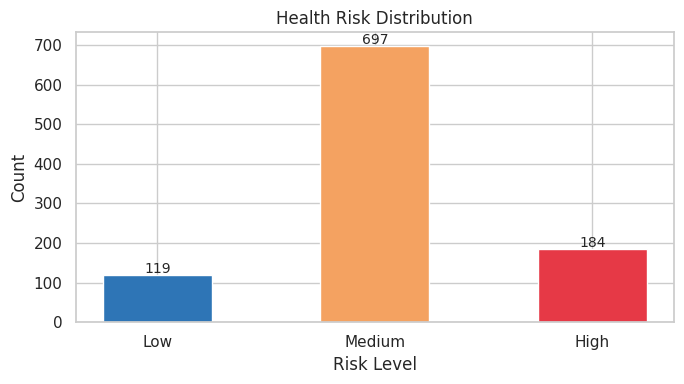

In [48]:
counts = df['health_risk'].value_counts().reindex(['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[l] for l in counts.index], width=0.5, edgecolor='white')

for bar in bars:
    val = int(bar.get_height())
    ax.text(bar.get_x() + bar.get_width()/2, val + 5,
            str(val), ha='center', fontsize=10)

ax.set_title('Health Risk Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 8.2 Confusion Matrices

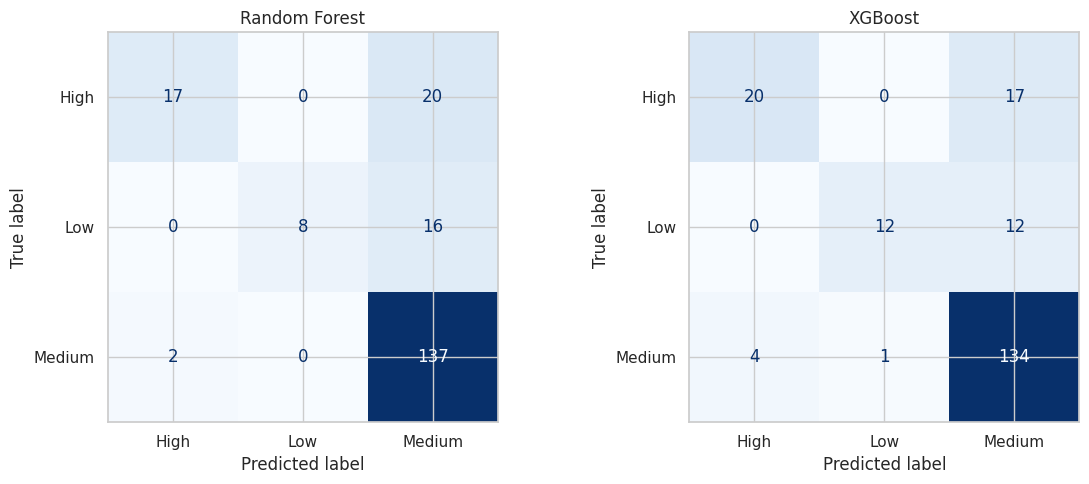

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_test_pred),
                       display_labels=le.classes_).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest')

ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_test_pred),
                       display_labels=le.classes_).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost')

plt.tight_layout()
plt.show()

### 8.3 Learning Curves

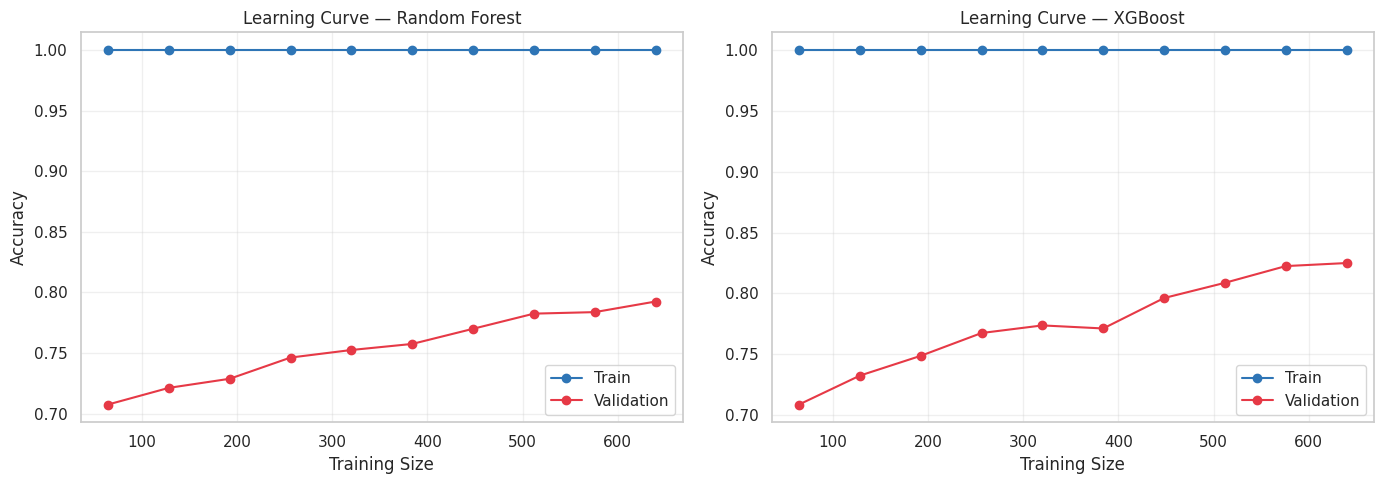

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [(rf, 'Random Forest'), (xgb, 'XGBoost')]

for i in range(2):
    model, name = models[i]
    ax = axes[i]

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2E75B6', label='Train')
    ax.plot(train_sizes, val_mean, 'o-', color='#E63946', label='Validation')
    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Correlation Heatmap

In [ ]:
orig_cols = ['Sleep_Hours', 'Stress_Level', 'CRP', 'Fasting_Glucose', 'LDL', 'HDL',
             'Triglycerides', 'ALT', 'AST', 'Rumination_Score', 'Mood_Score',
             'Focus_Level', 'Physical_Activity', 'Meditation_Minutes']

corr = df[orig_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1, center=0)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### 8.5 Biomarker Distributions

In [ ]:
bio_features = ['CRP', 'Fasting_Glucose', 'LDL', 'Triglycerides', 'ALT', 'HDL']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(len(bio_features)):
    feat = bio_features[i]
    ax = axes[i]
    for label in ['Low', 'Medium', 'High']:
        subset = df[df['health_risk'] == label][feat].dropna()
        subset.plot.kde(ax=ax, label=label, color=COLORS[label], linewidth=2)
    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Biomarker Distributions by Risk Group')
plt.tight_layout()
plt.show()

### 8.6 Composite Feature Distributions

In [ ]:
comp_feats = ['metabolic_risk_index', 'psych_burden_score',
              'neurochemical_balance', 'lifestyle_quality', 'inflammation_index']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(len(comp_feats)):
    feat = comp_feats[i]
    ax = axes[i]
    for label in ['Low', 'Medium', 'High']:
        subset = df[df['health_risk'] == label][feat].dropna()
        subset.plot.kde(ax=ax, label=label, color=COLORS[label], linewidth=2)
    ax.set_title(feat.replace('_', ' '))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Composite Feature Distributions by Risk Group')
plt.tight_layout()
plt.show()

### 8.7 Feature Importance

In [ ]:
importances = xgb.feature_importances_
feat_names = feature_cols_cl

# sort by importance
sorted_idx = np.argsort(importances)
top_idx = sorted_idx[-20:]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([feat_names[i].replace('_', ' ') for i in top_idx],
        [importances[i] for i in top_idx],
        color='#2E75B6', edgecolor='white')
ax.set_title('Top 20 Feature Importances — XGBoost')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.8 Model Comparison

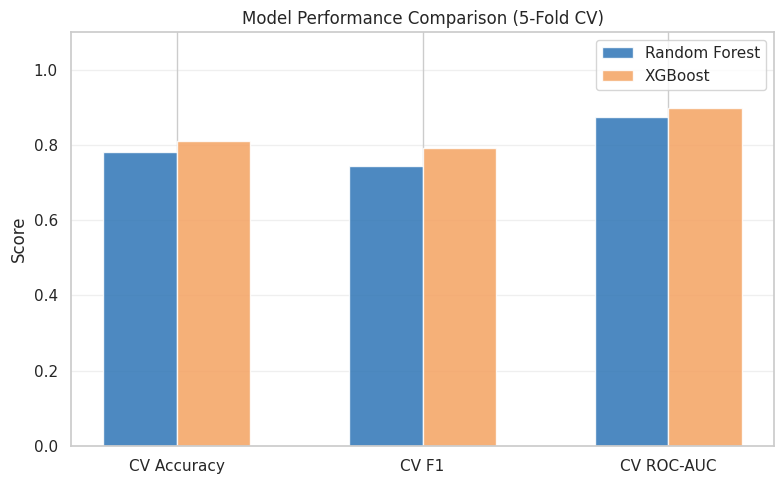

In [55]:
metric_names = ['CV Accuracy', 'CV F1', 'CV ROC-AUC']
rf_scores  = [rf_cv['test_accuracy'].mean(),  rf_cv['test_f1_weighted'].mean(),  rf_cv['test_roc_auc_ovr_weighted'].mean()]
xgb_scores = [xgb_cv['test_accuracy'].mean(), xgb_cv['test_f1_weighted'].mean(), xgb_cv['test_roc_auc_ovr_weighted'].mean()]

x = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - 0.15, rf_scores,  0.3, label='Random Forest', color='#2E75B6', alpha=0.85)
ax.bar(x + 0.15, xgb_scores, 0.3, label='XGBoost',       color='#F4A261', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (5-Fold CV)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.9 SHAP

In [ ]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols_cl, plot_type='bar')